In [4]:
%load_ext autoreload
%autoreload 2

In [165]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../fourier/')
import frequency_estimate as fe
import signals as sg

## No leakage

In [58]:
fsample = 2
fsignal = 0.02

T1 = 1000
T2 = 300

In [60]:
s1 = sg.cosine(T1, fsignal, fsample)
s2 = sg.cosine(T2, fsignal, fsample)

(-49.975, 1049.475)

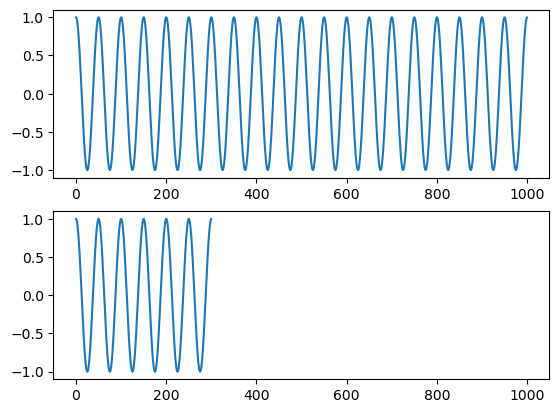

In [61]:
f, (ax,ax1) = plt.subplots(2,1,)
ax.plot(*s1, label='s1')
ax1.plot(*s2, label='s2')
ax1.set_xlim(*ax.get_xlim())

In [64]:
p1 = fe.periodogram(s1[1], fsample)
p2 = fe.periodogram(s2[1], fsample)

(0.0, 0.05)

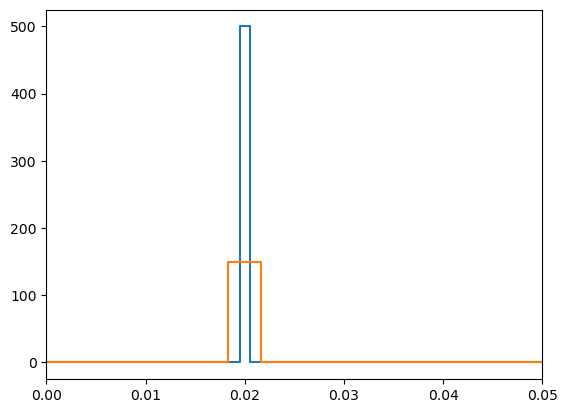

In [68]:
plt.step(*p1, where='mid')
plt.step(*p2, where='mid')
plt.xlim(0, 0.05)

In [74]:
df1 = p1[0][1]
df2 = p2[0][1]

In [76]:
df1, df2

(0.001, 0.0033333333333333335)

In [84]:
pow1 = p1[1][np.argmin(abs(p1[0] - fsignal))] * df1
pow2 = p2[1][np.argmin(abs(p2[0] - fsignal))] * df2

In [88]:
pow1 - pow2

-5.551115123125783e-17

## With leakage

In [92]:
fsample = 2
fsignal = 0.0243531

T1 = 1000
T2 = 300

In [94]:
s1 = sg.cosine(T1, fsignal, fsample)
s2 = sg.cosine(T2, fsignal, fsample)

(-49.975, 1049.475)

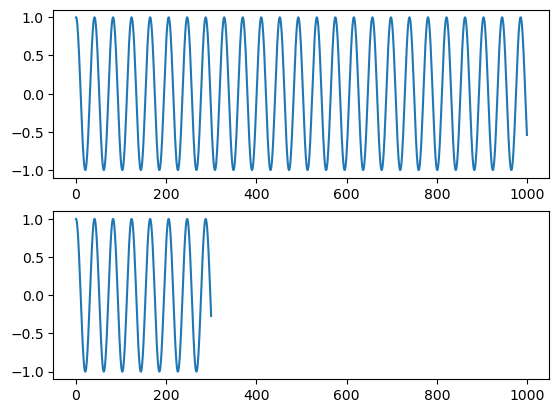

In [96]:
f, (ax,ax1) = plt.subplots(2,1,)
ax.plot(*s1, label='s1')
ax1.plot(*s2, label='s2')
ax1.set_xlim(*ax.get_xlim())

In [98]:
p1 = fe.periodogram(s1[1], fsample)
p2 = fe.periodogram(s2[1], fsample)

(0.0, 0.05)

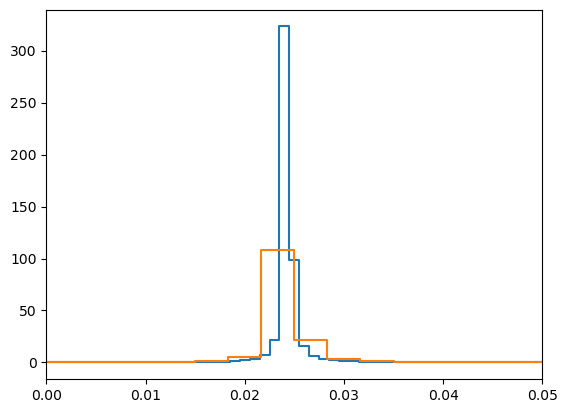

In [100]:
plt.step(*p1, where='mid')
plt.step(*p2, where='mid')
plt.xlim(0, 0.05)

In [102]:
df1 = p1[0][1]
df2 = p2[0][1]

In [104]:
df1, df2

(0.001, 0.0033333333333333335)

In [126]:
idx1 = np.argmax(p1[1])
p1[1][idx1:idx1+2]

array([323.20033517,  98.44847471])

In [128]:
idx2 = np.argmax(p2[1])
p2[1][idx2:idx2+2]

array([107.92350718,  21.77092322])

In [130]:
pow1 = p1[1][idx1:idx1+2].sum() * df1
pow2 = p2[1][idx2:idx2+2].sum() * df2

In [132]:
pow1 - pow2

-0.010665958118968089

In [134]:
pow1, pow2

(0.4216488098775506, 0.4323147679965187)

## With leakage + minimize leakage

In [167]:
fsample = 2
fsignal = 0.0243531

T1 = 1000
T2 = 300

In [169]:
s1 = sg.cosine(T1, fsignal, fsample)
s2 = sg.cosine(T2, fsignal, fsample)

(-49.975, 1049.475)

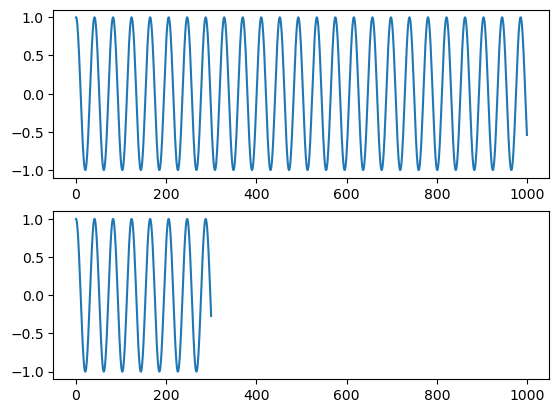

In [171]:
f, (ax,ax1) = plt.subplots(2,1,)
ax.plot(*s1, label='s1')
ax1.plot(*s2, label='s2')
ax1.set_xlim(*ax.get_xlim())

In [173]:
p1 = fe.symmetric_peak_periodogram(s1[1], fsample, 1/fsignal, signal_band=(0.01, 0.03))
p2 = fe.symmetric_peak_periodogram(s2[1], fsample, 1/fsignal, signal_band=(0.01, 0.03))

(0.0, 0.05)

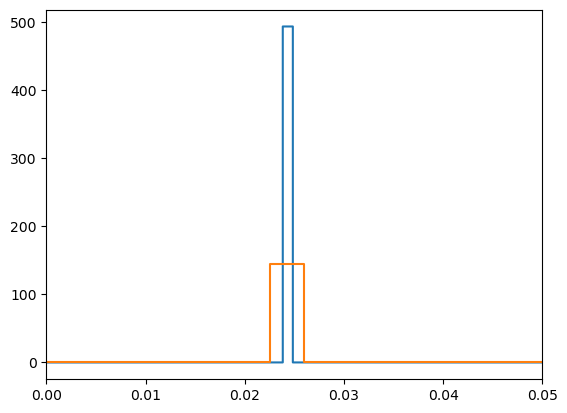

In [181]:
plt.step(p1['frequencies'], p1['power'], where='mid')
plt.step(p2['frequencies'], p2['power'], where='mid')
plt.xlim(0, 0.05)